Heart Disease Prediction Using Machine Learning

Internship Project

Student Name: Sanika Narale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries Imported Successfully")

Libraries Imported Successfully


In [2]:
df = pd.read_csv("/content/heart_disease_data.csv")

print("Dataset Shape:", df.shape)

df.head()

Dataset Shape: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [4]:
print(df.isnull().sum())

age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64


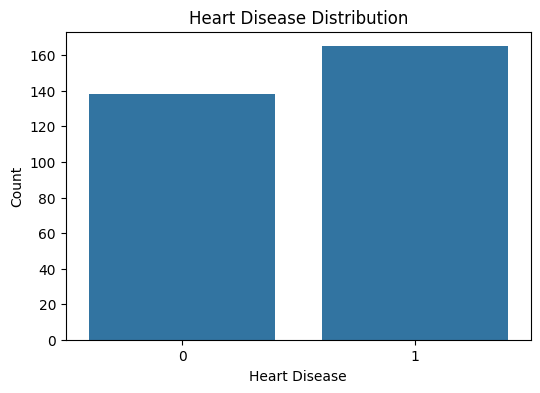

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df)
plt.title("Heart Disease Distribution")
plt.xlabel("Heart Disease")
plt.ylabel("Count")
plt.show()

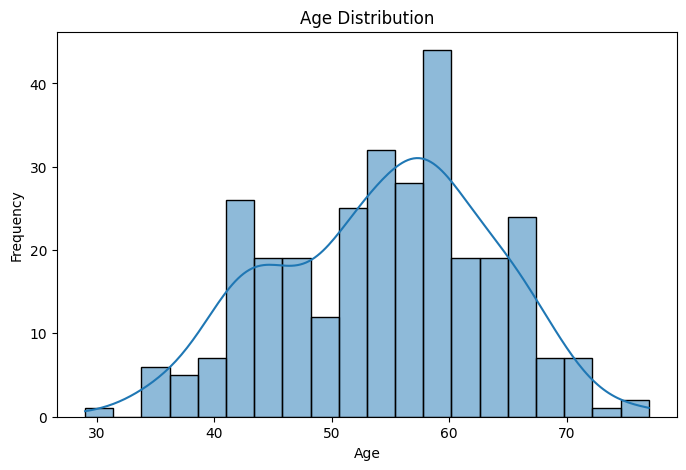

In [6]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

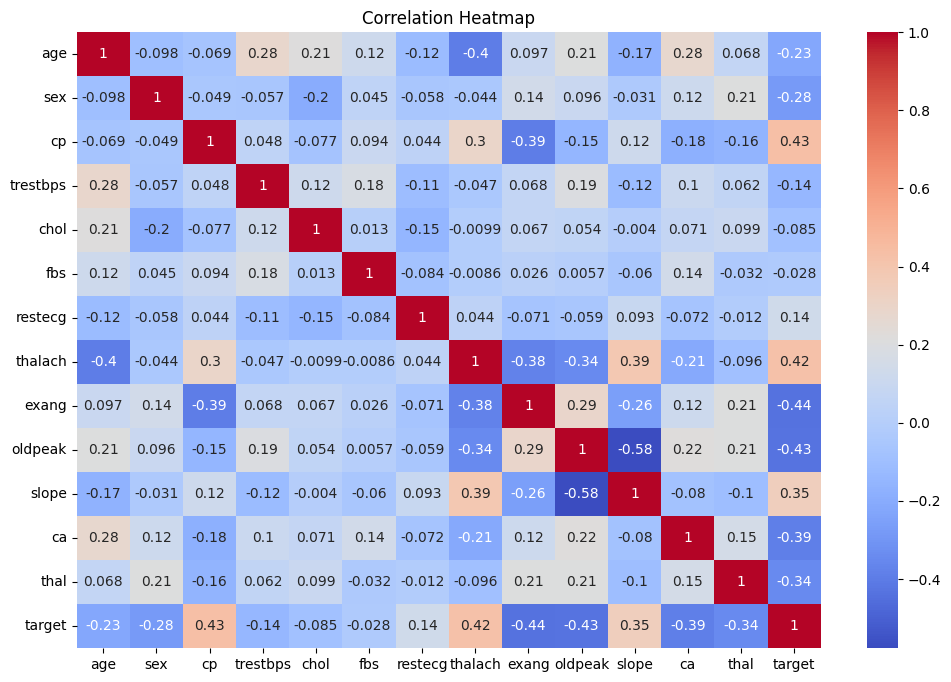

In [7]:
plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

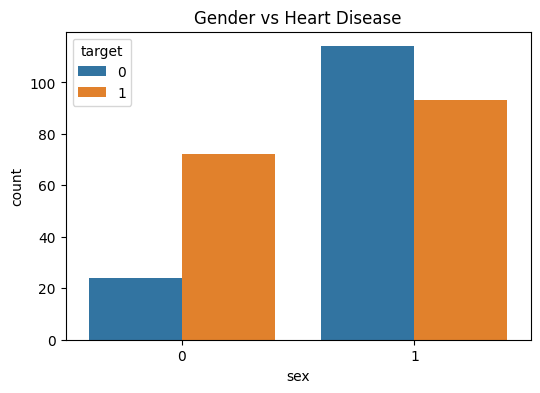

In [20]:
plt.figure(figsize=(6,4))
sns.countplot(x='sex', hue='target', data=df)
plt.title("Gender vs Heart Disease")
plt.show()

In [8]:

# Split Data into Features and Target


from sklearn.model_selection import train_test_split

# X = input columns
X = df.drop('target', axis=1)

# y = output column
y = df['target']

# Split into training and testing data
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Data Split Successfully")

Data Split Successfully


In [9]:

# Logistic Regression Model


from sklearn.linear_model import LogisticRegression

# Create Model
model = LogisticRegression(max_iter=1000)

# Train Model
model.fit(X_train, y_train)

print("Model Trained Successfully")

Model Trained Successfully


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [10]:

# Make Predictions


y_pred = model.predict(X_test)

print("Prediction Completed")

Prediction Completed


In [11]:
# Check Accuracy

from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y_test, y_pred)

print("Model Accuracy:", round(accuracy*100,2), "%")

Model Accuracy: 86.89 %


In [23]:
print("Test Accuracy :", accuracy)

Test Accuracy : 0.8688524590163934


In [12]:
# Classification Report

from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.86      0.86      0.86        29
           1       0.88      0.88      0.88        32

    accuracy                           0.87        61
   macro avg       0.87      0.87      0.87        61
weighted avg       0.87      0.87      0.87        61



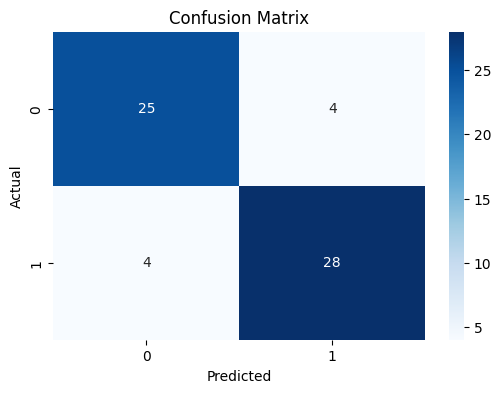

In [21]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [17]:

# Heart Disease Prediction System


import numpy as np

# Sample Patient Data
input_data = (63,1,3,145,233,1,0,150,0,2.3,0,0,1)

# Convert to NumPy Array
input_data = np.asarray(input_data).reshape(1,-1)

# Predict
prediction = model.predict(input_data)


print(" HEART DISEASE PREDICTION SYSTEM ")


if prediction[0] == 0:
    print("Risk Level : LOW")
    print("Prediction : No Heart Disease Detected")
else:
    print("Risk Level : HIGH")
    print("Prediction : Heart Disease Detected")
    print("The Person Has Heart Disease")

 HEART DISEASE PREDICTION SYSTEM 
Risk Level : HIGH
Prediction : Heart Disease Detected
The Person Has Heart Disease


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)

rf_accuracy = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", round(rf_accuracy*100,2), "%")

Random Forest Accuracy: 83.61 %


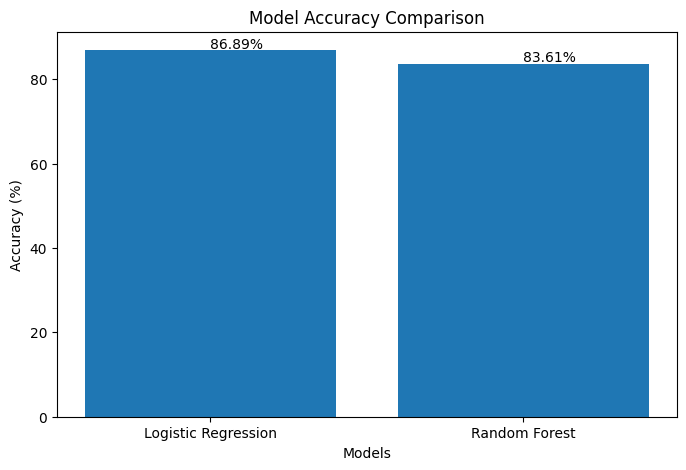

In [19]:
import matplotlib.pyplot as plt

models = ['Logistic Regression', 'Random Forest']

accuracies = [
    86.89,
    rf_accuracy*100
]

plt.figure(figsize=(8,5))

plt.bar(models, accuracies)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

for i, value in enumerate(accuracies):
    plt.text(i, value + 0.5, f"{value:.2f}%")

plt.show()